importer les bibliotheque

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import SGDRegressor


Generer data et noise





In [4]:
x = np.random.rand(10000)*10
y =50 * x + 35
y = y + np.random.randn(10000) * 100

generer outlier

In [5]:
# Generate 100 outlier points
num_outliers = 100
x_outliers = np.random.rand(num_outliers) * 10 # Generate x values within a similar range
y_outliers = 100 + np.random.randn(num_outliers) * 200 # Generate y values far from the original data

# Add outliers to the original data
x = np.concatenate((x, x_outliers))
y = np.concatenate((y, y_outliers))

print(f"Added {num_outliers} outliers. New data size: {len(x)}")

Added 100 outliers. New data size: 10100


plot the data

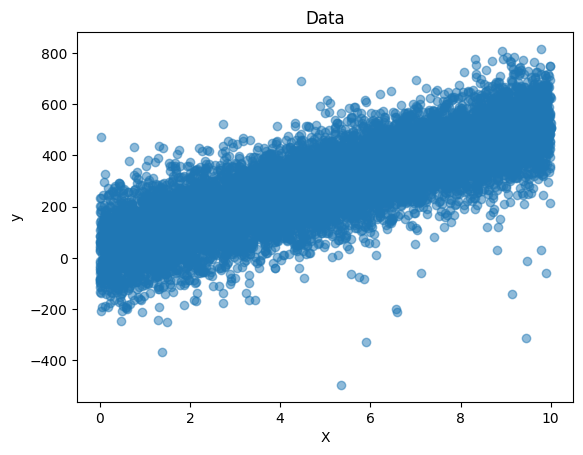

In [6]:
plt.scatter(x, y, alpha=0.5)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Data")
plt.show()

Linear regression from SKitlearn

Intercept (theta_0): 36.582565683405164
Slope (theta_1): 49.38410413915782

Regression Metrics:
Mean Absolute Error (MAE): 81.5023
Mean Squared Error (MSE): 10653.3948
Root Mean Squared Error (RMSE): 103.2153
R-squared (R2): 0.6548


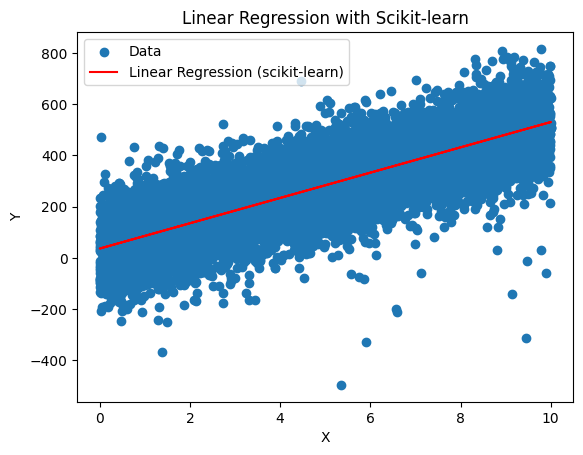

In [7]:
# Reshape x to be a 2D array as required by scikit-learn
x_reshaped = x.reshape(-1, 1)

# Create a Linear Regression model
model_skit_lr = LinearRegression()

# Fit the model to the data
model_skit_lr.fit(x_reshaped, y)

# Make predictions
y_pred = model_skit_lr.predict(x_reshaped)

# Calculate and print metrics
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("Intercept (theta_0):", model_skit_lr.intercept_)
print("Slope (theta_1):", model_skit_lr.coef_[0])
print("\nRegression Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")
plt.scatter(x, y, label='Data')
plt.plot(x_reshaped, y_pred, color='red', label='Linear Regression (scikit-learn)')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression with Scikit-learn')
plt.legend()
plt.show()


Generated 2000 validation data points in a different range.


Text(0, 0.5, 'Y')

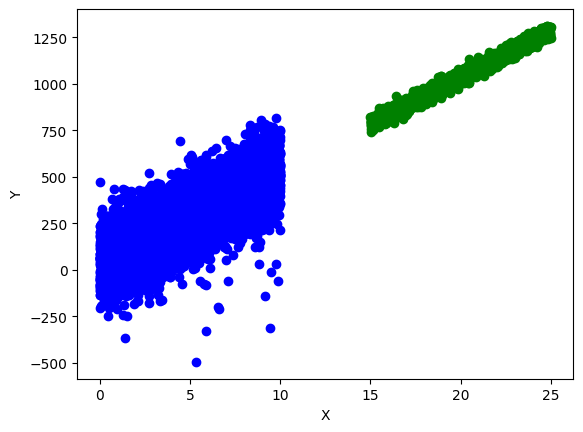

In [8]:
# Generate validation data far from the training data
num_validation_points = 2000
X_validation = np.random.rand(num_validation_points) * 10 + 15  # Generate x values in a different range (e.g., 15 to 25)
Y_validation = 50 * X_validation + 35 + np.random.randn(num_validation_points) * 20 # Use the same linear relationship with noise

print(f"Generated {num_validation_points} validation data points in a different range.")
plt.scatter(x, y, label='Data', color='blue')
plt.scatter(X_validation, Y_validation, label='Validation Data', color='green')
plt.xlabel('X')
plt.ylabel('Y')

Validation Metrics:
Mean Squared Error (MSE): 536.0999
R-squared (R2): 0.9753


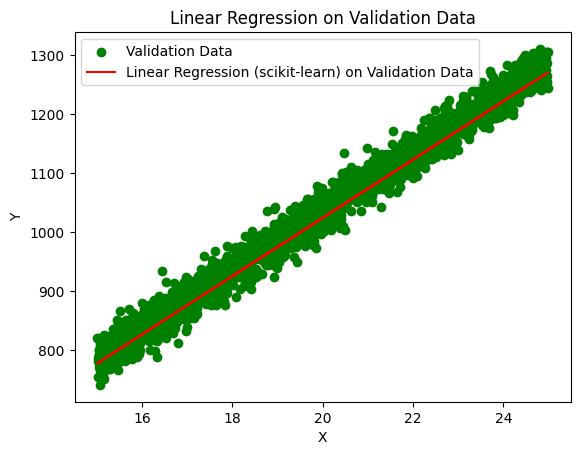

In [9]:

# Reshape X_validation to be a 2D array
X_validation_reshaped = X_validation.reshape(-1, 1)

# Make predictions on the validation data
y_validation_pred = model_skit_lr.predict(X_validation_reshaped)

# Calculate metrics on the validation data
mse_validation = mean_squared_error(Y_validation, y_validation_pred)
r2_validation = r2_score(Y_validation, y_validation_pred)

print("Validation Metrics:")
print(f"Mean Squared Error (MSE): {mse_validation:.4f}")
print(f"R-squared (R2): {r2_validation:.4f}")

# Plot the validation data and the regression line
plt.scatter(X_validation, Y_validation, label='Validation Data', color='green')
plt.plot(X_validation_reshaped, y_validation_pred, color='red', label='Linear Regression (scikit-learn) on Validation Data')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression on Validation Data')
plt.legend()
plt.show()

R-squared on Training Data: 0.6543390494956002
R-squared on Testing Data: 0.656685032689567


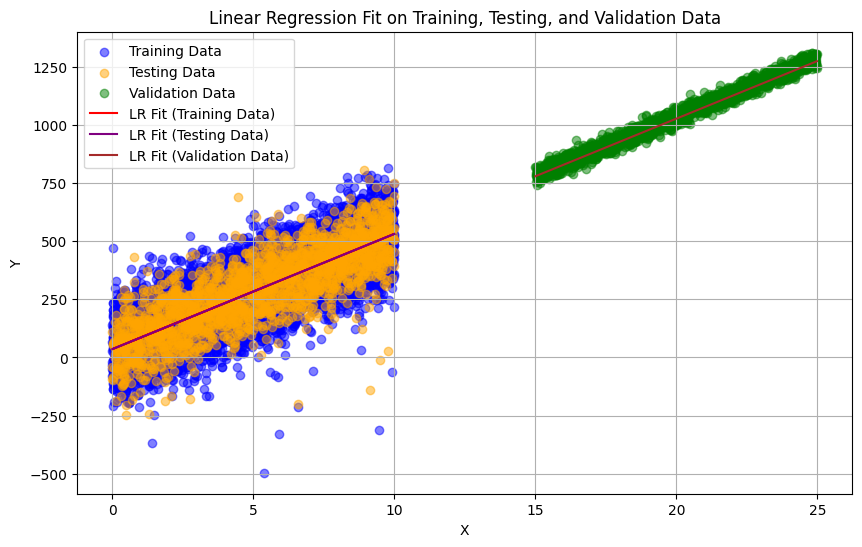

In [10]:

# Split the data into training and testing sets
# We'll use 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(x.reshape(-1, 1), y, test_size=0.2, random_state=42)

# Create a Linear Regression model
model_split = LinearRegression()

# Train the model on the training data
model_split.fit(X_train, y_train)

# Make predictions on the training and testing data
y_train_pred = model_split.predict(X_train)
y_test_pred = model_split.predict(X_test)

# Calculate R-squared for both training and testing sets
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("R-squared on Training Data:", r2_train)
print("R-squared on Testing Data:", r2_test)

# --- Plotting ---

plt.figure(figsize=(10, 6))

# Plot training data
plt.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.5)
# Plot testing data
plt.scatter(X_test, y_test, color='orange', label='Testing Data', alpha=0.5)
# Plot validation data (assuming X_validation and Y_validation are available)
if 'X_validation' in locals() and 'Y_validation' in locals():
    plt.scatter(X_validation, Y_validation, color='green', label='Validation Data', alpha=0.5)

# Plot regression line fitted on training data
plt.plot(X_train, y_train_pred, color='red', label='LR Fit (Training Data)')

# Plot regression line fitted on testing data (using model trained on training data)
# We need to sort X_test for the line plot to be correct
X_test_sorted, y_test_pred_sorted = zip(*sorted(zip(X_test.flatten(), y_test_pred)))
plt.plot(X_test_sorted, y_test_pred_sorted, color='purple', label='LR Fit (Testing Data)')

# Plot regression line fitted on validation data (using model trained on training data)
# We need to sort X_validation for the line plot to be correct
if 'X_validation' in locals() and 'Y_validation' in locals():
    y_validation_pred_plot = model_split.predict(X_validation.reshape(-1, 1))
    X_validation_sorted, y_validation_pred_plot_sorted = zip(*sorted(zip(X_validation.flatten(), y_validation_pred_plot)))
    plt.plot(X_validation_sorted, y_validation_pred_plot_sorted, color='brown', label='LR Fit (Validation Data)')


plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression Fit on Training, Testing, and Validation Data')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
X_b = np.c_[np.ones((len(x), 1)), x]
theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

print("Intercept (theta_0):", theta[0])
print("Slope (theta_1):", theta[1])

Intercept (theta_0): 36.58256568340495
Slope (theta_1): 49.38410413915787


/tmp/ipython-input-3929700571.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(X_new, y_predict, "r-", label="droite de regression lineaire", color='red')


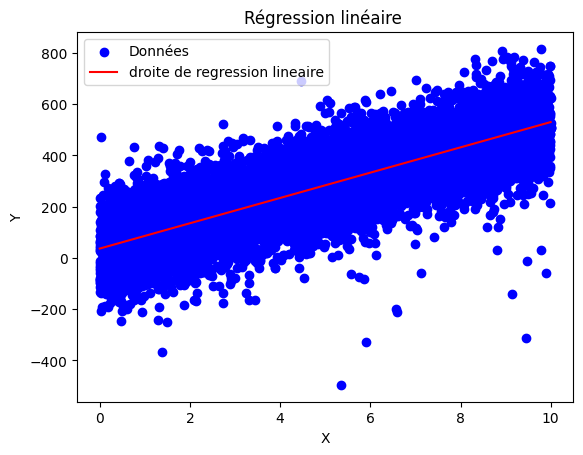

In [12]:
plt.scatter(x, y, label='Données', color='blue')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Régression linéaire ')

X_new = np.linspace(x.min(), x.max(), 10000).reshape(-1, 1) # Adjust range and reshape
X_new_b = np.c_[np.ones((len(X_new), 1)), X_new] # Match the number of ones to X_new
y_predict = X_new_b.dot(theta)
plt.plot(X_new, y_predict, "r-", label="droite de regression lineaire", color='red')
plt.legend()
plt.show()

In [13]:
def J(theta_0, theta_1, X, Y):
 m = len(Y)
 y_pred= theta_0 + theta_1 * X
 cost = (1/(2*m)) * np.sum((y_pred - Y)**2)
 return cost

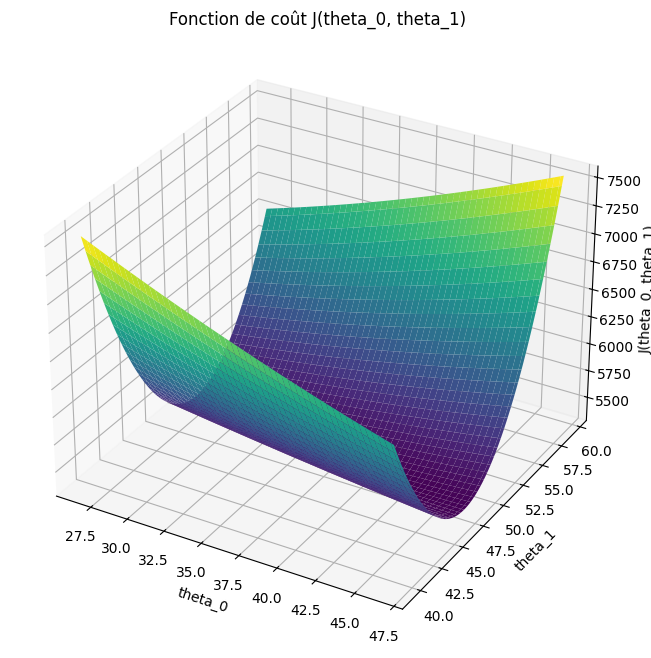

In [14]:
theta_0_vals = np.linspace(theta[0] - 10, theta[0] + 10, 100)
theta_1_vals = np.linspace(theta[1] - 10, theta[1] + 10, 100)
T0, T1 = np.meshgrid(theta_0_vals, theta_1_vals)

J_vals = np.array([J(t0, t1, x, y) for t0, t1 in zip(np.ravel(T0), np.ravel(T1))])
J_vals = J_vals.reshape(T0.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(T0, T1, J_vals, cmap='viridis')
ax.set_xlabel('theta_0')
ax.set_ylabel('theta_1')
ax.set_zlabel('J(theta_0, theta_1)')
ax.set_title('Fonction de coût J(theta_0, theta_1)')
plt.show()

In [15]:
def gradients(teta0, teta1, x, y):
  m = len(y)
  y_pred = teta0 + teta1 * x
  dt1 = (1/m) * np.sum((y_pred - y) * x)
  dt0 = (1/m) * np.sum(y_pred - y)
  return dt0, dt1

In [16]:
def update(t0,t1, dt0,dt1,r): # Removed default value for r
  t0 = t0-r*dt0
  t1 = t1-r*dt1
  return t0, t1

def descent(X, Y, learning_rate=0.01, epochs=1000): # Renamed parameters for clarity
  t0 = np.random.randn()
  t1 = np.random.randn()
  history = []

  for i in range(epochs):
    dt0,dt1 =gradients(t0, t1, X, Y)
    t0, t1 = update(t0, t1, dt0, dt1, learning_rate) # Pass learning_rate
    c = J(t0, t1, X, Y)
    history.append(c)
    if (i + 1) % 100 == 0:
        print(f"Epoch {i+1}/{epochs} Cost: {c}")

  return t0, t1,history

In [17]:
t0_gd, t1_gd,history = descent(x, y)
print("Parametres obtenus:")
print("Intercept (teta0):", t0_gd)
print("Slope (teta1):", t1_gd)
print(f"\nLinear equation obtained from Gradient Descent: y = {t0_gd:.4f} + {t1_gd:.4f} * x")

Epoch 100/1000 Cost: 5391.231147014111
Epoch 200/1000 Cost: 5366.446642372033
Epoch 300/1000 Cost: 5351.18075116087
Epoch 400/1000 Cost: 5341.777802107153
Epoch 500/1000 Cost: 5335.986102842185
Epoch 600/1000 Cost: 5332.418734755406
Epoch 700/1000 Cost: 5330.221432291248
Epoch 800/1000 Cost: 5328.868014869344
Epoch 900/1000 Cost: 5328.034384202747
Epoch 1000/1000 Cost: 5327.520913578647
Parametres obtenus:
Intercept (teta0): 34.003047908021344
Slope (teta1): 49.773623784435216

Linear equation obtained from Gradient Descent: y = 34.0030 + 49.7736 * x


/tmp/ipython-input-3153182705.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(X_new, y_predict_normal_eq, "r-", label="Prédiction de l'équation normale", color='red')
/tmp/ipython-input-3153182705.py:12: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  plt.plot(X_new, y_predict_gd, "g-", label="Prédiction de la descente de gradient", color='green')


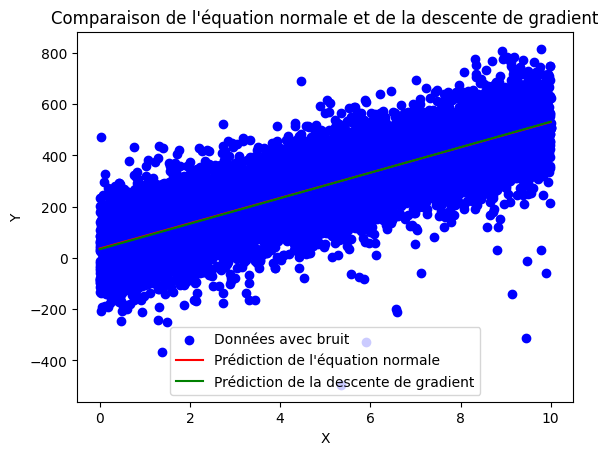

In [18]:
plt.scatter(x, y, label='Données avec bruit', color='blue')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Comparaison de l\'équation normale et de la descente de gradient')

X_new = np.linspace(x.min(), x.max(), 100) # Use the range of x
X_new_b = np.c_[np.ones((len(X_new), 1)), X_new]
y_predict_normal_eq = X_new_b.dot(theta)
plt.plot(X_new, y_predict_normal_eq, "r-", label="Prédiction de l'équation normale", color='red')

y_predict_gd = t0_gd + t1_gd * X_new
plt.plot(X_new, y_predict_gd, "g-", label="Prédiction de la descente de gradient", color='green')

plt.legend()
plt.show()

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
filepath= '/content/drive/MyDrive/Machine Learning/new_dataset.csv'
data=pd.read_csv(filepath)

In [21]:
data.head()
data.count()

,0
X,1000
y,1000


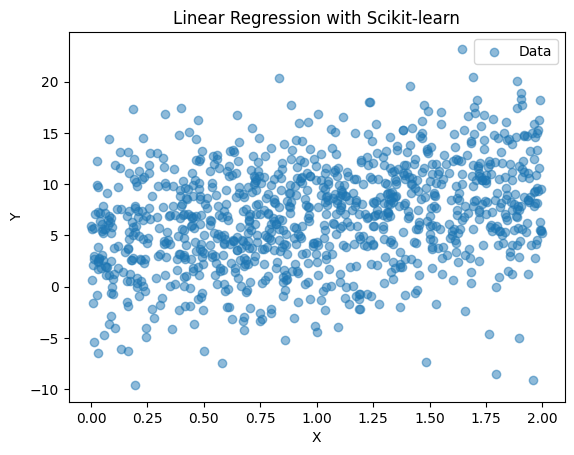

NameError: name 'X_vector_reshaped' is not defined

In [23]:


# Define columns as vectors
X_vector = data.iloc[:,0]
y_vector = data.iloc[:,1]

plt.scatter(X_vector, y_vector, label='Data', alpha=0.5)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression with Scikit-learn')
plt.legend()
plt.show()

# Create a Linear Regression model
model_skit_lr = LinearRegression()

# Fit the model to the data
model_skit_lr.fit(X_vector_reshaped, y_vector)

# Make predictions
y_pred = model_skit_lr.predict(X_vector_reshaped)

# Calculate and print metrics
mae = mean_absolute_error(y_vector, y_pred)
mse = mean_squared_error(y_vector, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_vector, y_pred)

print("Intercept (theta_0):", model_skit_lr.intercept_)
print("Slope (theta_1):", model_skit_lr.coef_[0])
print("\nRegression Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Plotting
plt.scatter(X_vector, y_vector, label='Data')
plt.plot(X_vector_reshaped, y_pred, color='red', label='Linear Regression (scikit-learn)')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression with Scikit-learn')
plt.legend()
plt.show()

In [ ]:

# Split the data into training and testing sets
# We'll use 80% for training and 20% for testing
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_vector.values.reshape(-1, 1), y_vector, test_size=0.2, random_state=42)

# Create a Linear Regression model
model_new_split = LinearRegression()

# Train the model on the training data
model_new_split.fit(X_train_new, y_train_new)

# Make predictions on the training and testing data
y_train_pred_new = model_new_split.predict(X_train_new)
y_test_pred_new = model_new_split.predict(X_test_new)

# Calculate metrics for training and testing sets
mae_train_new = mean_absolute_error(y_train_new, y_train_pred_new)
mse_train_new = mean_squared_error(y_train_new, y_train_pred_new)
rmse_train_new = np.sqrt(mse_train_new)
r2_train_new = r2_score(y_train_new, y_train_pred_new)

mae_test_new = mean_absolute_error(y_test_new, y_test_pred_new)
mse_test_new = mean_squared_error(y_test_new, y_test_pred_new)
rmse_test_new = np.sqrt(mse_test_new)
r2_test_new = r2_score(y_test_new, y_test_pred_new)


print("Training Metrics:")
print(f"Mean Absolute Error (MAE): {mae_train_new:.4f}")
print(f"Mean Squared Error (MSE): {mse_train_new:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_train_new:.4f}")
print(f"R-squared (R2): {r2_train_new:.4f}")

print("\nTesting Metrics:")
print(f"Mean Absolute Error (MAE): {mae_test_new:.4f}")
print(f"Mean Squared Error (MSE): {mse_test_new:.4f}")
print(f"R-squared (R2): {r2_test_new:.4f}")


# --- Plotting ---

plt.figure(figsize=(10, 6))

# Plot training data
plt.scatter(X_train_new, y_train_new, color='blue', label='Training Data', alpha=0.5)
# Plot testing data
plt.scatter(X_test_new, y_test_new, color='orange', label='Testing Data', alpha=0.5)

# Plot regression line fitted on training data
# Sort X_train_new for correct line plotting
X_train_new_sorted, y_train_pred_new_sorted = zip(*sorted(zip(X_train_new.flatten(), y_train_pred_new)))
plt.plot(X_train_new_sorted, y_train_pred_new_sorted, color='red', label='LR Fit (Training Data)')

# Plot regression line fitted on testing data (using model trained on training data)
# Sort X_test_new for correct line plotting
X_test_new_sorted, y_test_pred_new_sorted = zip(*sorted(zip(X_test_new.flatten(), y_test_pred_new)))
plt.plot(X_test_new_sorted, y_test_pred_new_sorted, color='purple', label='LR Fit (Testing Data)')


plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression Fit on New Data (Training and Testing)')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipython-input-410109385.py:49: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  model_sgd.fit(X_train, y_train.ravel())
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/tmp/ipython-input-410109385.py:49: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  model_sgd.fit(X_train, y_train.ravel())
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/tmp/ipython-input-410109385.py:49: FutureWarnin


🏆 Meilleur Modèle trouvé :
Learning Rate optimal : 0.05
Nombre d'Epochs optimal : 4
R² (Test) maximal : 0.1483
Intercept : 3.923
Coefficient : 2.867


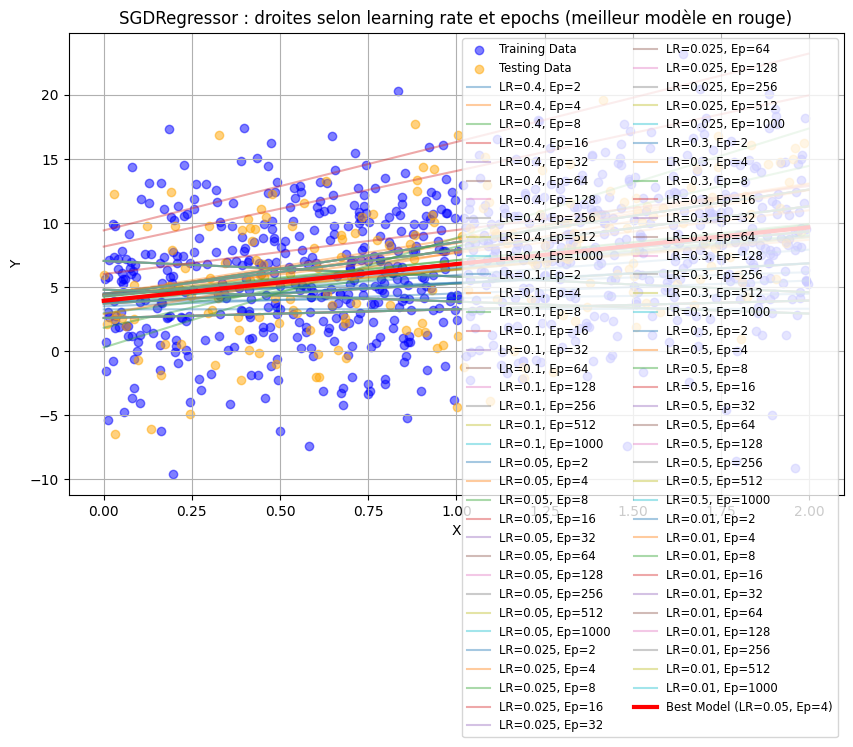

In [25]:
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# --- Extraction des vecteurs depuis ton DataFrame ---
X_vector = data.iloc[:, 0]
y_vector = data.iloc[:, 1]

# --- Division du jeu de données en train/test ---
X_train, X_test, y_train, y_test = train_test_split(
    X_vector.values.reshape(-1, 1),
    y_vector,
    test_size=0.2,
    random_state=42
)

# --- Hyperparamètres à tester ---
learning_rate = [0.4, 0.1, 0.05, 0.025, 0.3, 0.5,0.01]
n_epochs = [2,4,8, 16, 32,64, 128, 256, 512, 1000]

# --- Variables pour stocker le meilleur modèle ---
best_r2 = -np.inf
best_lr = None
best_epoch = None
best_model = None

# --- Création d'une seule figure ---
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.5)
plt.scatter(X_test, y_test, color='orange', label='Testing Data', alpha=0.5)

# --- Génération de points pour tracer les droites de régression ---
X_plot = np.linspace(X_vector.min(), X_vector.max(), 100).reshape(-1, 1)

# --- Boucle sur les hyperparamètres ---
for learning_rate_sgd in learning_rate:
    for n_epochs_sgd in n_epochs:
        model_sgd = SGDRegressor(
            loss='squared_error',
            max_iter=n_epochs_sgd,
            eta0=learning_rate_sgd,
            learning_rate='constant',
            random_state=42
        )

        # Entraînement du modèle
        model_sgd.fit(X_train, y_train.ravel())

        # Évaluation
        r2_test = r2_score(y_test, model_sgd.predict(X_test))

        # --- Stocker le meilleur modèle ---
        if r2_test > best_r2:
            best_r2 = r2_test
            best_lr = learning_rate_sgd
            best_epoch = n_epochs_sgd
            best_model = model_sgd

        # --- Tracé de la droite correspondante ---
        y_plot = model_sgd.predict(X_plot)
        plt.plot(X_plot, y_plot, label=f'LR={learning_rate_sgd}, Ep={n_epochs_sgd}', alpha=0.4)

# --- Affichage du meilleur modèle ---
print("\n🏆 Meilleur Modèle trouvé :")
print(f"Learning Rate optimal : {best_lr}")
print(f"Nombre d'Epochs optimal : {best_epoch}")
print(f"R² (Test) maximal : {best_r2:.4f}")
print(f"Intercept : {best_model.intercept_[0]:.3f}")
print(f"Coefficient : {best_model.coef_[0]:.3f}")

# --- Tracé de la meilleure droite en rouge épais ---
y_best = best_model.predict(X_plot)
plt.plot(X_plot, y_best, color='red', linewidth=3, label=f'Best Model (LR={best_lr}, Ep={best_epoch})')

# --- Présentation finale ---
plt.xlabel('X')
plt.ylabel('Y')
plt.title("SGDRegressor : droites selon learning rate et epochs (meilleur modèle en rouge)")
plt.legend(fontsize='small', ncol=2)
plt.grid(True)
plt.show()

regresion polynomiyal siktlearn + programme personel de degre 2

---



Epoch 200/3000 | Coût: 16.956368
Epoch 400/3000 | Coût: 14.946615
Epoch 600/3000 | Coût: 14.314516
Epoch 800/3000 | Coût: 13.913677
Epoch 1000/3000 | Coût: 13.587667
Epoch 1200/3000 | Coût: 13.309849
Epoch 1400/3000 | Coût: 13.071352
Epoch 1600/3000 | Coût: 12.866377
Epoch 1800/3000 | Coût: 12.690177
Epoch 2000/3000 | Coût: 12.538703
Epoch 2200/3000 | Coût: 12.408480
Epoch 2400/3000 | Coût: 12.296520
Epoch 2600/3000 | Coût: 12.200257
Epoch 2800/3000 | Coût: 12.117485
Epoch 3000/3000 | Coût: 12.046307

--- Résultats finaux ---
θ₀ = 3.5980, θ₁ = 0.5787, θ₂ = 1.6495
Coût final = 12.046307


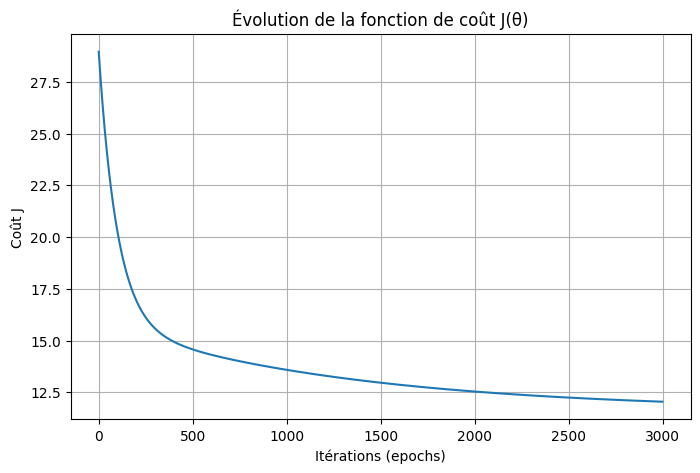

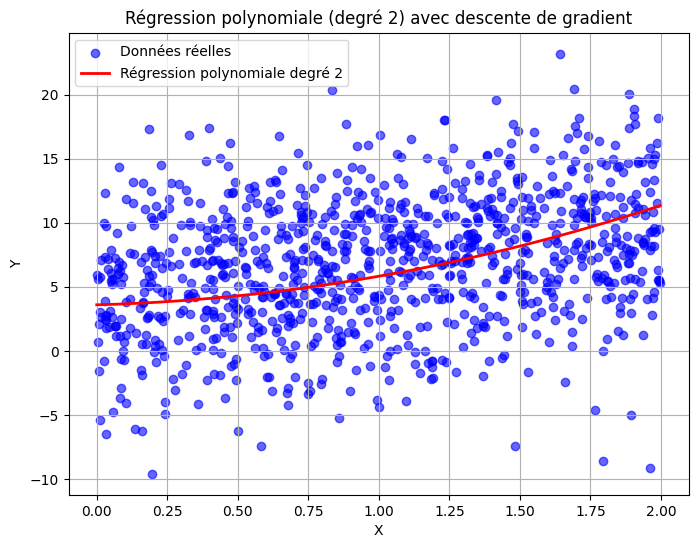

Epoch 200/3000 | Coût: 23.302212
Epoch 400/3000 | Coût: 14.546679
Epoch 600/3000 | Coût: 13.203433
Epoch 800/3000 | Coût: 12.853049
Epoch 1000/3000 | Coût: 12.656500
Epoch 1200/3000 | Coût: 12.501181
Epoch 1400/3000 | Coût: 12.369463
Epoch 1600/3000 | Coût: 12.256488
Epoch 1800/3000 | Coût: 12.159423
Epoch 2000/3000 | Coût: 12.076004
Epoch 2200/3000 | Coût: 12.004311
Epoch 2400/3000 | Coût: 11.942694
Epoch 2600/3000 | Coût: 11.889738
Epoch 2800/3000 | Coût: 11.844225
Epoch 3000/3000 | Coût: 11.805109

--- Résultats finaux ---
θ₀ = 3.1816, θ₁ = 2.5428, θ₂ = 0.5684
Coût final = 11.805109


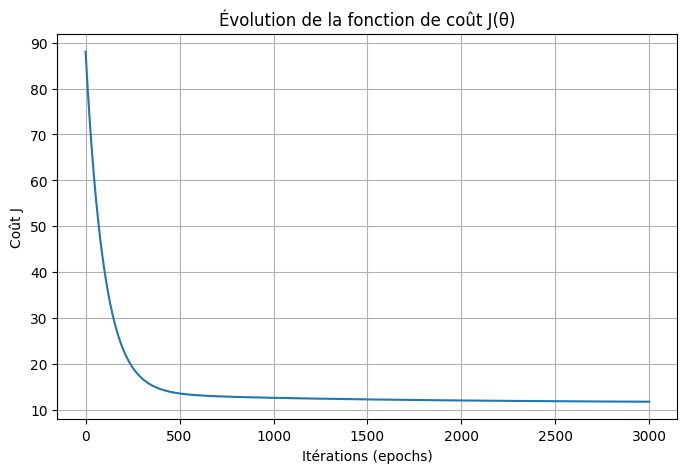

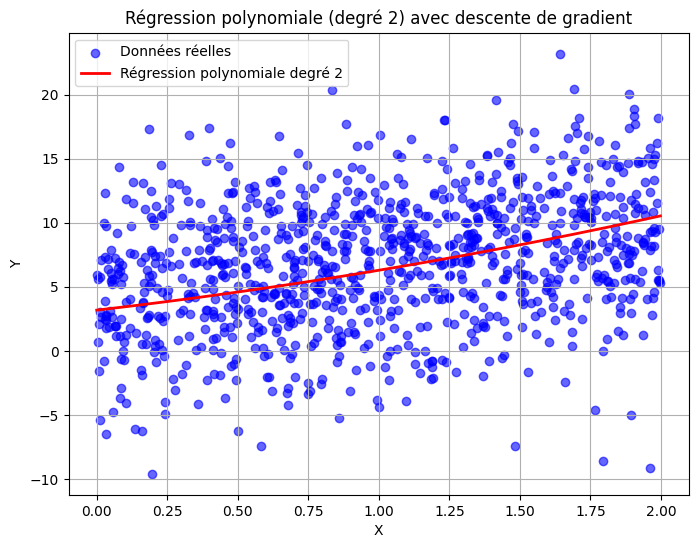

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# --- Extraction des colonnes du DataFrame ---
X = X_vector.values
Y = y_vector.values
m = len(Y)

# --- Fonction de coût ---
def J(theta0, theta1, theta2, X, Y):
    Y_pred = theta0 + theta1 * X + theta2 * (X**2)
    cost = (1/(2*m)) * np.sum((Y_pred - Y)**2)
    return cost

# --- Calcul des gradients ---
def gradients(theta0, theta1, theta2, X, Y):
    Y_pred = theta0 + theta1 * X + theta2 * (X**2)
    dtheta0 = (1/m) * np.sum(Y_pred - Y)
    dtheta1 = (1/m) * np.sum((Y_pred - Y) * X)
    dtheta2 = (1/m) * np.sum((Y_pred - Y) * (X**2))
    return dtheta0, dtheta1, dtheta2

# --- Mise à jour des paramètres ---
def update(theta0, theta1, theta2, dtheta0, dtheta1, dtheta2, lr):
    theta0 -= lr * dtheta0
    theta1 -= lr * dtheta1
    theta2 -= lr * dtheta2
    return theta0, theta1, theta2

# --- Descente de gradient principale ---
def gradient_descent_poly2(X, Y, lr=0.001, epochs=2000):
    theta0 = np.random.randn()
    theta1 = np.random.randn()
    theta2 = np.random.randn()
    history = []

    for i in range(epochs):
        dtheta0, dtheta1, dtheta2 = gradients(theta0, theta1, theta2, X, Y)
        theta0, theta1, theta2 = update(theta0, theta1, theta2, dtheta0, dtheta1, dtheta2, lr)
        cost = J(theta0, theta1, theta2, X, Y)
        history.append(cost)

        if (i + 1) % 200 == 0:
            print(f"Epoch {i+1}/{epochs} | Coût: {cost:.6f}")

    return theta0, theta1, theta2, history

# --- Entraînement ---
theta0, theta1, theta2, history = gradient_descent_poly2(X, Y, lr=0.001, epochs=3000)

# --- Résultats finaux ---
print("\n--- Résultats finaux ---")
print(f"θ₀ = {theta0:.4f}, θ₁ = {theta1:.4f}, θ₂ = {theta2:.4f}")
print(f"Coût final = {history[-1]:.6f}")

# --- Courbe du coût ---
plt.figure(figsize=(8,5))
plt.plot(history)
plt.title("Évolution de la fonction de coût J(θ)")
plt.xlabel("Itérations (epochs)")
plt.ylabel("Coût J")
plt.grid(True)
plt.show()

# --- Visualisation du modèle ---
plt.figure(figsize=(8,6))
plt.scatter(X, Y, color='blue', label='Données réelles', alpha=0.6)
X_plot = np.linspace(min(X), max(X), 200)
Y_pred = theta0 + theta1 * X_plot + theta2 * (X_plot**2)
plt.plot(X_plot, Y_pred, color='red', linewidth=2, label='Régression polynomiale degré 2')
plt.title("Régression polynomiale (degré 2) avec descente de gradient")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()
import numpy as np
import matplotlib.pyplot as plt

# --- Extraction des colonnes du DataFrame ---
X = X_vector.values
Y = y_vector.values
m = len(Y)

# --- Fonction de coût ---
def J(theta0, theta1, theta2, X, Y):
    Y_pred = theta0 + theta1 * X + theta2 * (X**2)
    cost = (1/(2*m)) * np.sum((Y_pred - Y)**2)
    return cost

# --- Calcul des gradients ---
def gradients(theta0, theta1, theta2, X, Y):
    Y_pred = theta0 + theta1 * X + theta2 * (X**2)
    dtheta0 = (1/m) * np.sum(Y_pred - Y)
    dtheta1 = (1/m) * np.sum((Y_pred - Y) * X)
    dtheta2 = (1/m) * np.sum((Y_pred - Y) * (X**2))
    return dtheta0, dtheta1, dtheta2

# --- Mise à jour des paramètres ---
def update(theta0, theta1, theta2, dtheta0, dtheta1, dtheta2, lr):
    theta0 -= lr * dtheta0
    theta1 -= lr * dtheta1
    theta2 -= lr * dtheta2
    return theta0, theta1, theta2

# --- Descente de gradient principale ---
def gradient_descent_poly2(X, Y, lr=0.001, epochs=2000):
    theta0 = np.random.randn()
    theta1 = np.random.randn()
    theta2 = np.random.randn()
    history = []

    for i in range(epochs):
        dtheta0, dtheta1, dtheta2 = gradients(theta0, theta1, theta2, X, Y)
        theta0, theta1, theta2 = update(theta0, theta1, theta2, dtheta0, dtheta1, dtheta2, lr)
        cost = J(theta0, theta1, theta2, X, Y)
        history.append(cost)

        if (i + 1) % 200 == 0:
            print(f"Epoch {i+1}/{epochs} | Coût: {cost:.6f}")

    return theta0, theta1, theta2, history

# --- Entraînement ---
theta0, theta1, theta2, history = gradient_descent_poly2(X, Y, lr=0.001, epochs=3000)

# --- Résultats finaux ---
print("\n--- Résultats finaux ---")
print(f"θ₀ = {theta0:.4f}, θ₁ = {theta1:.4f}, θ₂ = {theta2:.4f}")
print(f"Coût final = {history[-1]:.6f}")

# --- Courbe du coût ---
plt.figure(figsize=(8,5))
plt.plot(history)
plt.title("Évolution de la fonction de coût J(θ)")
plt.xlabel("Itérations (epochs)")
plt.ylabel("Coût J")
plt.grid(True)
plt.show()

# --- Visualisation du modèle ---
plt.figure(figsize=(8,6))
plt.scatter(X, Y, color='blue', label='Données réelles', alpha=0.6)
X_plot = np.linspace(min(X), max(X), 200)
Y_pred = theta0 + theta1 * X_plot + theta2 * (X_plot**2)
plt.plot(X_plot, Y_pred, color='red', linewidth=2, label='Régression polynomiale degré 2')
plt.title("Régression polynomiale (degré 2) avec descente de gradient")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()


Degree 1:
  Training - RMSE: 4.8400, R2: 0.0813
  Testing  - RMSE: 4.6929, R2: 0.1410
--------------------
Degree 2:
  Training - RMSE: 4.8398, R2: 0.0814
  Testing  - RMSE: 4.6939, R2: 0.1407
--------------------
Degree 3:
  Training - RMSE: 4.8393, R2: 0.0816
  Testing  - RMSE: 4.7001, R2: 0.1384
--------------------
Degree 5:
  Training - RMSE: 4.8284, R2: 0.0857
  Testing  - RMSE: 4.7133, R2: 0.1335
--------------------
Degree 10:
  Training - RMSE: 4.8266, R2: 0.0864
  Testing  - RMSE: 4.7096, R2: 0.1349
--------------------
Degree 15:
  Training - RMSE: 4.8196, R2: 0.0890
  Testing  - RMSE: 4.7069, R2: 0.1359
--------------------


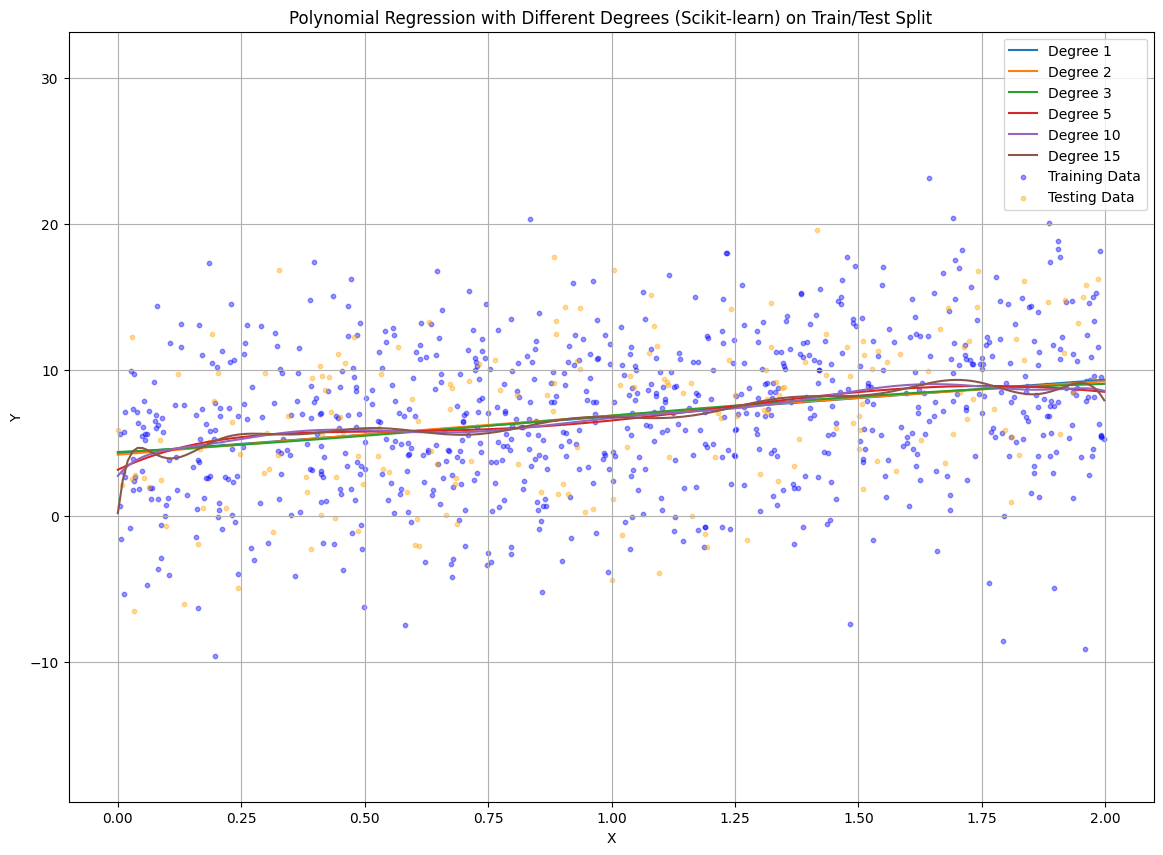

In [29]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'data' DataFrame is loaded with 'X' and 'y' columns

# Extract features (X) and target (y) from the DataFrame
X_data = data['X'].values.reshape(-1, 1)
y_data = data['y'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# Define a list of polynomial degrees to test
degrees = [1, 2, 3, 5, 10, 15] # You can add or change degrees here

plt.figure(figsize=(14, 10))

# Iterate through the defined degrees
for degree in degrees:
    # Create polynomial features
    # include_bias=False to avoid multicollinearity with the intercept in LinearRegression
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)

    # Fit and transform training data
    X_train_poly = poly_features.fit_transform(X_train)
    # Transform testing data (do not fit on test data)
    X_test_poly = poly_features.transform(X_test)

    # Create a Linear Regression model
    model_poly = LinearRegression()

    # Train the model on the polynomial features of the training data
    model_poly.fit(X_train_poly, y_train)

    # Make predictions on training and testing data
    y_train_pred = model_poly.predict(X_train_poly)
    y_test_pred = model_poly.predict(X_test_poly)

    # Calculate and print metrics for training and testing sets
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    r2_train = r2_score(y_train, y_train_pred)

    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    r2_test = r2_score(y_test, y_test_pred)


    print(f"Degree {degree}:")
    print(f"  Training - RMSE: {rmse_train:.4f}, R2: {r2_train:.4f}")
    print(f"  Testing  - RMSE: {rmse_test:.4f}, R2: {r2_test:.4f}")
    print("-" * 20)

    # --- Plotting ---
    # Create a range of x values for plotting the fitted curve smoothly
    X_plot = np.linspace(X_data.min(), X_data.max(), 200).reshape(-1, 1)
    X_plot_poly = poly_features.transform(X_plot)
    y_plot_poly = model_poly.predict(X_plot_poly)

    # Plot the fitted polynomial regression line
    plt.plot(X_plot, y_plot_poly, label=f'Degree {degree}')


# Plot the original training and testing data points
plt.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.4, s=10)
plt.scatter(X_test, y_test, color='orange', label='Testing Data', alpha=0.4, s=10)


plt.xlabel('X')
plt.ylabel('Y')
plt.title('Polynomial Regression with Different Degrees (Scikit-learn) on Train/Test Split')
plt.legend()
plt.grid(True)
plt.ylim(min(y_data) - 10, max(y_data) + 10) # Adjust y-axis limits for better visualization
plt.show()